# SNR Per-Crack Interactive Analysis

This notebook starts from a `snr_per_crack_*.csv` file exported by the Scanimator workflow.

Workflow:
1. Select one per-crack CSV file
2. Load the per-crack dataframe (`per_crack_df`)
3. Detect factors for data analysis

In [1]:
from pathlib import Path
from datetime import datetime

import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 200)

In [2]:
# Input controls
USE_GUI_PICKER = True
CSV_GLOB_PATTERN = "outputs/run_*/snr_per_crack*.csv"

# Optional: set an exact file path. If set, this takes priority over picker/glob.
PER_CRACK_CSV_PATH = None  # Example: "outputs/run_20260525_140100/snr_per_crack_20260525_140100.csv"

# When using glob, choose the newest matching file automatically.
PICK_MOST_RECENT_FROM_GLOB = True

In [ ]:
# Load per-crack CSV produced by Scanimator, add data analysis factors
selected_path = None

if PER_CRACK_CSV_PATH:
    selected_path = Path(PER_CRACK_CSV_PATH)
elif USE_GUI_PICKER:
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    try:
        picked = filedialog.askopenfilename(
            title="Select snr_per_crack CSV",
            initialdir=str((Path.cwd() / "outputs").resolve()),
            filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
        )
    finally:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plot_df = per_crack_df.copy()

if "Crack" not in plot_df.columns:
    if "manual_label" in plot_df.columns:
        plot_df["Crack"] = plot_df["manual_label"]
    else:
        raise KeyError("Need a Crack or manual_label column to group the box plot.")

material_order = [m for m in ["Aluminum", "Stainless Steel", "Titanium"] if m in plot_df["Material"].dropna().unique()]
if not material_order:
    material_order = sorted(plot_df["Material"].dropna().astype(str).unique())

frequency_order = [f for f in ["1.1", "2.4", "3.2"] if f in plot_df["Frequency"].dropna().unique()]
if not frequency_order:
    frequency_order = sorted(plot_df["Frequency"].dropna().astype(str).unique())

crack_order = list(dict.fromkeys(plot_df["Crack"].dropna().astype(str)))
palette = plt.get_cmap("tab10")
colors = {crack: palette(i % 10) for i, crack in enumerate(crack_order)}

fig, axes = plt.subplots(1, len(frequency_order), figsize=(6 * len(frequency_order), 5), sharey=True)
if len(frequency_order) == 1:
    axes = [axes]

box_width = 0.8 / max(len(crack_order), 1)
for ax, frequency in zip(axes, frequency_order):
    subset = plot_df[plot_df["Frequency"].astype(str) == str(frequency)]
    centers = list(range(len(material_order)))

    for material_index, material in enumerate(material_order):
        for crack_index, crack in enumerate(crack_order):
            values = subset.loc[(subset["Material"].astype(str) == str(material)) & (subset["Crack"].astype(str) == str(crack)), "peak_snr_db"].dropna().tolist()
            if not values:
                continue
            position = material_index - 0.4 + box_width / 2 + crack_index * box_width
            bp = ax.boxplot(values, positions=[position], widths=box_width * 0.9, patch_artist=True, manage_ticks=False)
            for box in bp["boxes"]:
                box.set_facecolor(colors[crack])
                box.set_alpha(0.75)
                box.set_edgecolor("black")
            for median in bp["medians"]:
                median.set_color("black")
            for whisker in bp["whiskers"]:
                whisker.set_color("black")
            for cap in bp["caps"]:
                cap.set_color("black")

    ax.set_title(f"Frequency: {frequency} MHz")
    ax.set_xticks(centers)
    ax.set_xticklabels(material_order, rotation=20)
    ax.set_xlabel("Material")
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Peak SNR (dB)")
fig.suptitle("Peak SNR by Material, Crack, and Frequency", y=1.02)
fig.legend([Patch(facecolor=colors[crack], edgecolor="black", alpha=0.75) for crack in crack_order], crack_order, title="Crack", loc="upper center", ncol=max(len(crack_order), 1), bbox_to_anchor=(0.5, 0.95))
fig.tight_layout()
plt.show()
        frequency = "3.2"

    inductor = None
    if "flex08" in name:
        inductor = "8-layer"
    elif "flex04" in name:
        inductor = "4-layer"
    elif "flex12" in name:
        inductor = "12-layer"

    return pd.Series({
        "Material": material,
        "Frequency": frequency,
        "Inductor": inductor,
    })

factor_groups = per_crack_df["file"].apply(derive_factor_groups)
per_crack_df = pd.concat([per_crack_df, factor_groups], axis=1)
keep_columns = ["file", "manual_label", "peak_x", "peak_y", "noise_floor",
    "noise_sigma", "peak_signal_amplitude", "peak_snr_linear", "peak_snr_db",
    "Material", "Frequency", "Inductor",
]
per_crack_df = per_crack_df[[c for c in keep_columns if c in per_crack_df.columns]]

print("Added factor-group columns: Material, Frequency, Inductor")
print("per_crack_df shape:", per_crack_df.shape)
display(per_crack_df.head(20))

Using per-crack CSV: C:\Users\newsp\ldcscanner\ldcscanner\outputs\material-frequency-cracks\snr_per_crack_20260525_132600.csv
Added factor-group columns: Material, Frequency, Inductor
per_crack_df shape: (54, 12)


,file,manual_label,peak_x,peak_y,noise_floor,noise_sigma,peak_signal_amplitude,peak_snr_linear,peak_snr_db,Material,Frequency,Inductor
0,1.1mhz_alum.csv,Crack 1,9299.545,44.548786,44.480344,0.002284,0.068442,29.965667,29.532479,Aluminum,1.1,NaN
1,1.1mhz_alum.csv,Crack 1,9305.525,44.552521,44.480159,0.002284,0.072362,31.681741,30.016181,Aluminum,1.1,NaN
2,1.1mhz_alum.csv,Crack 2,9258.006,44.738628,44.479147,0.002284,0.259481,113.607468,41.108138,Aluminum,1.1,NaN
3,1.1mhz_alum.csv,Crack 2,9267.012,44.735802,44.479757,0.002284,0.256045,112.102905,40.992337,Aluminum,1.1,NaN
4,1.1mhz_alum.csv,Crack 3,9201.410,44.987465,44.478531,0.002284,0.508934,222.824127,46.959244,Aluminum,1.1,NaN
5,1.1mhz_alum.csv,Crack 3,9209.913,44.994999,44.481033,0.002284,0.513966,225.027289,47.044704,Aluminum,1.1,NaN
6,1.1mhz_ss.csv,Crack 1,7334.274,45.619240,45.592649,0.004726,0.026591,5.626708,15.005087,Stainless Steel,1.1,NaN
7,1.1mhz_ss.csv,Crack 1,7358.163,45.620121,45.593266,0.004726,0.026855,5.682683,15.091068,Stainless Steel,1.1,NaN
8,1.1mhz_ss.csv,Crack 2,7375.270,45.763329,45.594093,0.004726,0.169236,35.811338,31.080411,Stainless Steel,1.1,NaN
9,1.1mhz_ss.csv,Crack 2,7431.109,45.765656,45.595370,0.004726,0.170286,36.033525,31.134135,Stainless Steel,1.1,NaN


Produce visualizations based on the factors in the file

Saved plot PDF: outputs\reports\snr_grouped_plots_20260525_154018.pdf


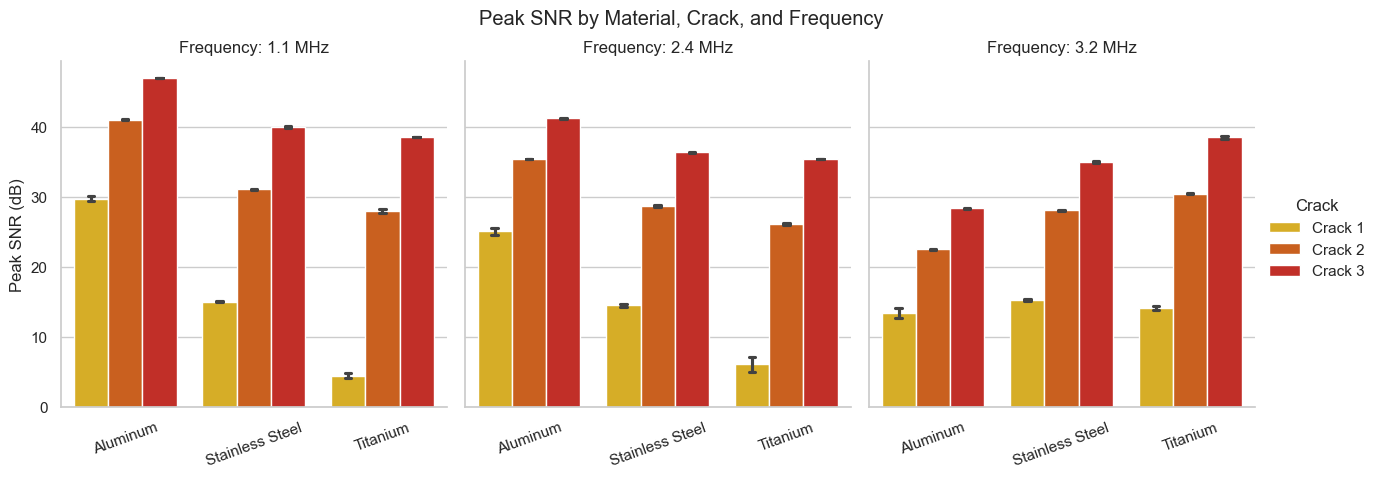

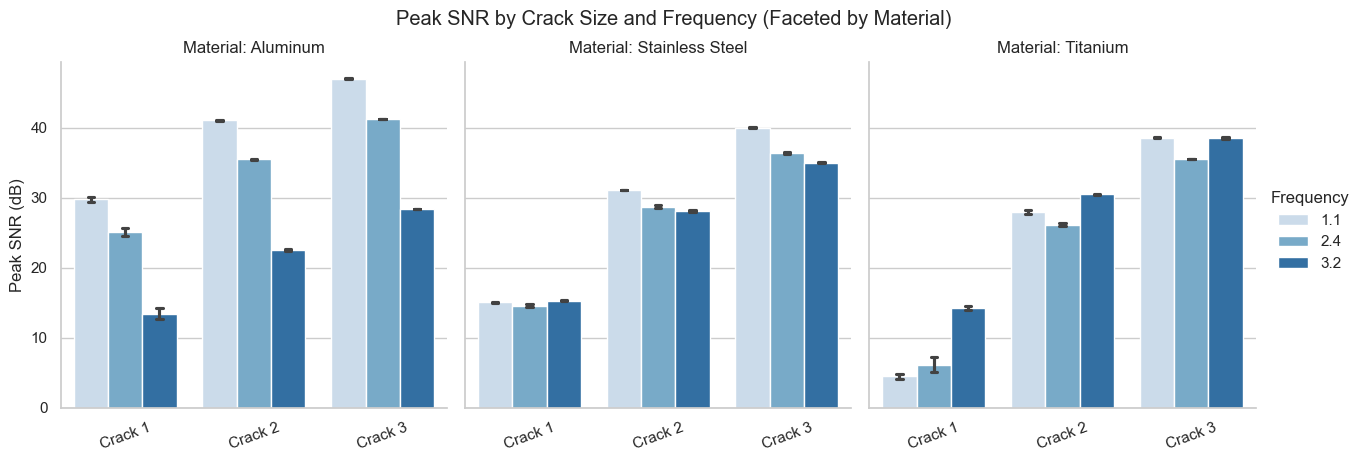

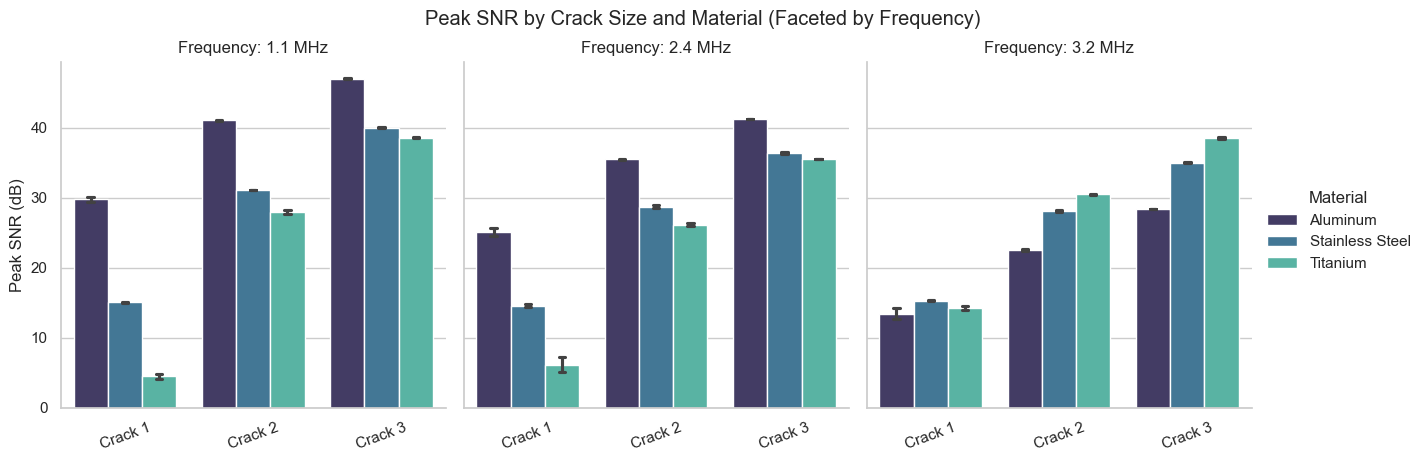

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from datetime import datetime
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import config as cfg

cfg = importlib.reload(cfg)
LABEL_COLOR_MAP = getattr(cfg, "LABEL_COLOR_MAP", {})
FREQUENCY_COLOR_MAP = getattr(cfg, "FREQUENCY_COLOR_MAP", {})
MATERIAL_COLOR_MAP = getattr(cfg, "MATERIAL_COLOR_MAP", {})

plot_df = per_crack_df.copy()

if "Crack" not in plot_df.columns:
    if "manual_label" in plot_df.columns:
        plot_df["Crack"] = plot_df["manual_label"]
    else:
        raise KeyError("Need a Crack or manual_label column to group the box plot.")

material_order = [m for m in ["Aluminum", "Stainless Steel", "Titanium"] if m in plot_df["Material"].dropna().unique()] or None
frequency_order = [f for f in ["1.1", "2.4", "3.2"] if f in plot_df["Frequency"].dropna().unique()] or None

def crack_size_key(label):
    text = str(label)
    lower = text.lower()
    if "not" in lower:
        return (99, lower)
    digits = "".join(ch for ch in text if ch.isdigit())
    if digits:
        return (int(digits), lower)
    return (98, lower)

hue_order = sorted(list(dict.fromkeys(plot_df["Crack"].dropna().astype(str))), key=crack_size_key) or None
fallback_palette = sns.color_palette("tab10", n_colors=max(len(hue_order or []), 1))
palette = {crack: LABEL_COLOR_MAP.get(crack, fallback_palette[i % len(fallback_palette)]) for i, crack in enumerate(hue_order or [])}

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=plot_df,
    x="Material",
    y="peak_snr_db",
    hue="Crack",
    col="Frequency",
    kind="bar",
    order=material_order,
    col_order=frequency_order,
    hue_order=hue_order,
    palette=palette if palette else None,
    estimator="mean",
    errorbar="sd",
    capsize=0.15,
    height=4.5,
    aspect=0.95,
    sharey=True,
)

g.set_axis_labels("", "Peak SNR (dB)")
g.set_titles("Frequency: {col_name} MHz")
g.fig.suptitle("Peak SNR by Material, Crack, and Frequency", y=1.03)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)

freq_fallback = sns.color_palette("Blues", n_colors=max(len(frequency_order or []), 1))
freq_palette = {freq: FREQUENCY_COLOR_MAP.get(freq, freq_fallback[i % len(freq_fallback)]) for i, freq in enumerate(frequency_order or [])}

g2 = sns.catplot(
    data=plot_df,
    x="Crack",
    y="peak_snr_db",
    hue="Frequency",
    col="Material",
    kind="bar",
    order=hue_order,
    hue_order=frequency_order,
    col_order=material_order,
    palette=freq_palette if freq_palette else None,
    estimator="mean",
    errorbar="sd",
    capsize=0.15,
    height=4.5,
    aspect=0.95,
    sharey=True,
)

g2.set_axis_labels("", "Peak SNR (dB)")
g2.set_titles("Material: {col_name}")
g2.fig.suptitle("Peak SNR by Crack Size and Frequency (Faceted by Material)", y=1.03)
for ax in g2.axes.flat:
    ax.tick_params(axis="x", rotation=20)

mat_fallback = sns.color_palette("mako", n_colors=max(len(material_order or []), 1))
mat_palette = {mat: MATERIAL_COLOR_MAP.get(mat, mat_fallback[i % len(mat_fallback)]) for i, mat in enumerate(material_order or [])}

g3 = sns.catplot(
    data=plot_df,
    x="Crack",
    y="peak_snr_db",
    hue="Material",
    col="Frequency",
    kind="bar",
    order=hue_order,
    hue_order=material_order,
    col_order=frequency_order,
    palette=mat_palette if mat_palette else None,
    estimator="mean",
    errorbar="sd",
    capsize=0.15,
    height=4.5,
    aspect=0.95,
    sharey=True,
)

g3.set_axis_labels("", "Peak SNR (dB)")
g3.set_titles("Frequency: {col_name} MHz")
g3.fig.suptitle("Peak SNR by Crack Size and Material (Faceted by Frequency)", y=1.03)
for ax in g3.axes.flat:
    ax.tick_params(axis="x", rotation=20)

pdf_dir = Path("outputs") / "reports"
pdf_dir.mkdir(parents=True, exist_ok=True)
pdf_path = pdf_dir / f"snr_grouped_plots_{datetime.now():%Y%m%d_%H%M%S}.pdf"
with PdfPages(pdf_path) as pdf:
    pdf.savefig(g.fig, bbox_inches="tight")
    pdf.savefig(g2.fig, bbox_inches="tight")
    pdf.savefig(g3.fig, bbox_inches="tight")
print(f"Saved plot PDF: {pdf_path}")

plt.show()